# Main Analysis: Human vs Model Aggregation

This notebook contains the core analysis comparing human and model collective decision-making:
1. **Majority voting** with group size effects (bootstrap)
2. **Weighted Logic Combiner (WLC)** with 10-fold cross-validation
3. **Signal Detection Theory metrics** (d', criterion, hit/false-alarm rates)

**Prerequisites:** Run `Data-Preparation.ipynb` first to load and validate raw data.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.data_loaders import load_human_master, load_model_master
from src.config import get_paths

paths = get_paths()
rng = np.random.default_rng(seed=42)

print(f"✓ Outputs: {paths.outputs_dir}")

✓ Outputs: C:\Users\AdamR\Projects\Flexible-Wisdom\outputs


## 1. Load Master Datasets

In [2]:
human_master = load_human_master()
model_master = load_model_master()

print(f"✓ Human: {human_master.shape[0]} trials, {human_master['participantID'].nunique()} participants")
print(f"✓ Model: {model_master.shape[0]} trials, {model_master['participantID'].nunique()} models")
display(human_master.head())
display(model_master.head())

✓ Human: 36000 trials, 12 participants
✓ Model: 36000 trials, 12 models


,stimID,condition,response,side_selected,cue_points,line1_angle,line2_angle,valid_cue,TP,participantID,decision
0,100,50_50,6,1,2,14.314827,1.921956,False,True,SA,1
1,845,50_50,5,1,2,15.054317,4.222230,False,True,SA,1
2,245,50_50,4,1,1,14.314827,6.508956,True,True,SA,1
3,72,50_50,4,2,2,8.775056,15.054317,True,True,SA,1
4,469,50_50,4,2,2,4.222230,19.885165,True,True,SA,1


,stimID,condition,side_selected,cue_points,line1_angle,line2_angle,valid_cue,TP,response,participantID,decision
0,100,50_50,1,2,14.314827,1.921956,False,True,present,0responses_claude-3-5-haiku-20241022,1
1,845,50_50,1,2,15.054317,4.222230,False,True,absent,0responses_claude-3-5-haiku-20241022,0
2,245,50_50,1,1,14.314827,6.508956,True,True,present,0responses_claude-3-5-haiku-20241022,1
3,72,50_50,2,2,8.775056,15.054317,True,True,absent,0responses_claude-3-5-haiku-20241022,0
4,469,50_50,2,2,4.222230,19.885165,True,True,absent,0responses_claude-3-5-haiku-20241022,0


## 2. Majority Voting Bootstrap Analysis

Test whether larger groups improve collective decision-making accuracy.

In [3]:
# Configuration
group_sizes = [1, 3, 5, 7, 11, 12]
n_boot = 500
conds = ["50_50", "80_20", "100_0"]

# Helper functions for majority voting
def majority_conf_vectorized(dec_mat, conf_mat, tp_vec):
    """Human majority rule: decisions + confidence tiebreak."""
    present_counts = np.nansum(dec_mat == 1, axis=1)
    absent_counts = np.nansum(dec_mat == 0, axis=1)
    
    gd = np.full(dec_mat.shape[0], np.nan)
    present_wins = present_counts > absent_counts
    absent_wins = absent_counts > present_counts
    
    gd[present_wins] = 1
    gd[absent_wins] = 0
    
    # Ties resolved by confidence
    ties = ~(present_wins | absent_wins)
    if np.any(ties):
        dec_tie = dec_mat[ties]
        conf_tie = conf_mat[ties]
        
        mask_present = (dec_tie == 1)
        mask_absent = (dec_tie == 0)
        
        with np.errstate(invalid="ignore"):
            conf_present_mean = np.where(
                mask_present.any(axis=1),
                np.nanmean(np.where(mask_present, conf_tie, np.nan), axis=1),
                np.nan
            )
            conf_absent_mean = np.where(
                mask_absent.any(axis=1),
                np.nanmean(np.where(mask_absent, conf_tie, np.nan), axis=1),
                np.nan
            )
        
        tie_idx = np.where(ties)[0]
        pres_better = conf_present_mean > conf_absent_mean
        gd[tie_idx[pres_better]] = 1
        
        abs_better = conf_absent_mean > conf_present_mean
        gd[tie_idx[abs_better]] = 0
        
        unresolved = np.isnan(gd[tie_idx])
        gd[tie_idx[unresolved]] = 1  # default to present
    
    correct = gd == tp_vec
    mask_valid = ~np.isnan(tp_vec)
    acc = correct[mask_valid].mean()
    return float(acc)

def majority_vectorized(dec_mat, tp_vec):
    """Model majority rule: simple majority, ties → present."""
    present_counts = np.nansum(dec_mat == 1, axis=1)
    absent_counts = np.nansum(dec_mat == 0, axis=1)
    
    gd = np.full(dec_mat.shape[0], np.nan)
    gd[present_counts > absent_counts] = 1
    gd[absent_counts > present_counts] = 0
    gd[(present_counts == absent_counts) & (present_counts > 0)] = 1  # ties
    
    correct = gd == tp_vec
    mask_valid = ~np.isnan(tp_vec)
    acc = correct[mask_valid].mean()
    return float(acc)

print("✓ Bootstrap majority voting functions defined")

✓ Bootstrap majority voting functions defined


In [4]:
# Run bootstrap analysis
records = []

for domain, df in [("human", human_master), ("model", model_master)]:
    print(f"\n=== {domain.upper()} ===")
    
    for cond in conds:
        dfc = df[df["condition"] == cond].copy()
        if dfc.empty:
            continue
        
        dec_pivot = dfc.pivot(index="stimID", columns="participantID", values="decision")
        tp_by_trial = (
            dfc.drop_duplicates("stimID")
               .set_index("stimID")["TP"]
               .reindex(dec_pivot.index)
               .to_numpy()
               .astype(float)
        )
        
        dec_mat = dec_pivot.to_numpy().astype(float)
        participants_cond = dec_pivot.columns.to_numpy()
        n_participants = len(participants_cond)
        
        valid_group_sizes = [g for g in group_sizes if g <= n_participants]
        
        if domain == "human":
            conf_pivot = dfc.pivot(index="stimID", columns="participantID", values="response")
            conf_mat = conf_pivot.to_numpy().astype(float)
        
        for g in valid_group_sizes:
            for b in range(n_boot):
                cols = rng.choice(n_participants, size=g, replace=False)
                dec_sample = dec_mat[:, cols]
                
                if domain == "human":
                    conf_sample = conf_mat[:, cols]
                    acc = majority_conf_vectorized(dec_sample, conf_sample, tp_by_trial)
                else:
                    acc = majority_vectorized(dec_sample, tp_by_trial)
                
                records.append({
                    "domain": domain,
                    "condition": cond,
                    "group_size": g,
                    "bootstrap": b,
                    "accuracy": acc
                })
        
        print(f"  {cond}: {n_participants} agents, group sizes {valid_group_sizes}")

results_df = pd.DataFrame(records)
summary_df = (
    results_df
    .groupby(["domain", "condition", "group_size"])["accuracy"]
    .agg(mean_acc="mean", std_acc="std")
    .reset_index()
)

print(f"\n✓ Bootstrap analysis complete ({len(records)} samples)")
display(summary_df.head(10))


=== HUMAN ===


  50_50: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  80_20: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  100_0: 12 agents, group sizes [1, 3, 5, 7, 11, 12]

=== MODEL ===


  50_50: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  80_20: 12 agents, group sizes [1, 3, 5, 7, 11, 12]


  100_0: 12 agents, group sizes [1, 3, 5, 7, 11, 12]

✓ Bootstrap analysis complete (18000 samples)


,domain,condition,group_size,mean_acc,std_acc
0,human,100_0,1,0.665576,0.107901
1,human,100_0,3,0.715176,0.070470
2,human,100_0,5,0.740958,0.054125
3,human,100_0,7,0.759498,0.040702
4,human,100_0,11,0.782264,0.012799
5,human,100_0,12,0.784000,0.000000
6,human,50_50,1,0.577740,0.075924
7,human,50_50,3,0.608408,0.058047
8,human,50_50,5,0.627500,0.048021
9,human,50_50,7,0.640844,0.034066


### Majority Voting Plots

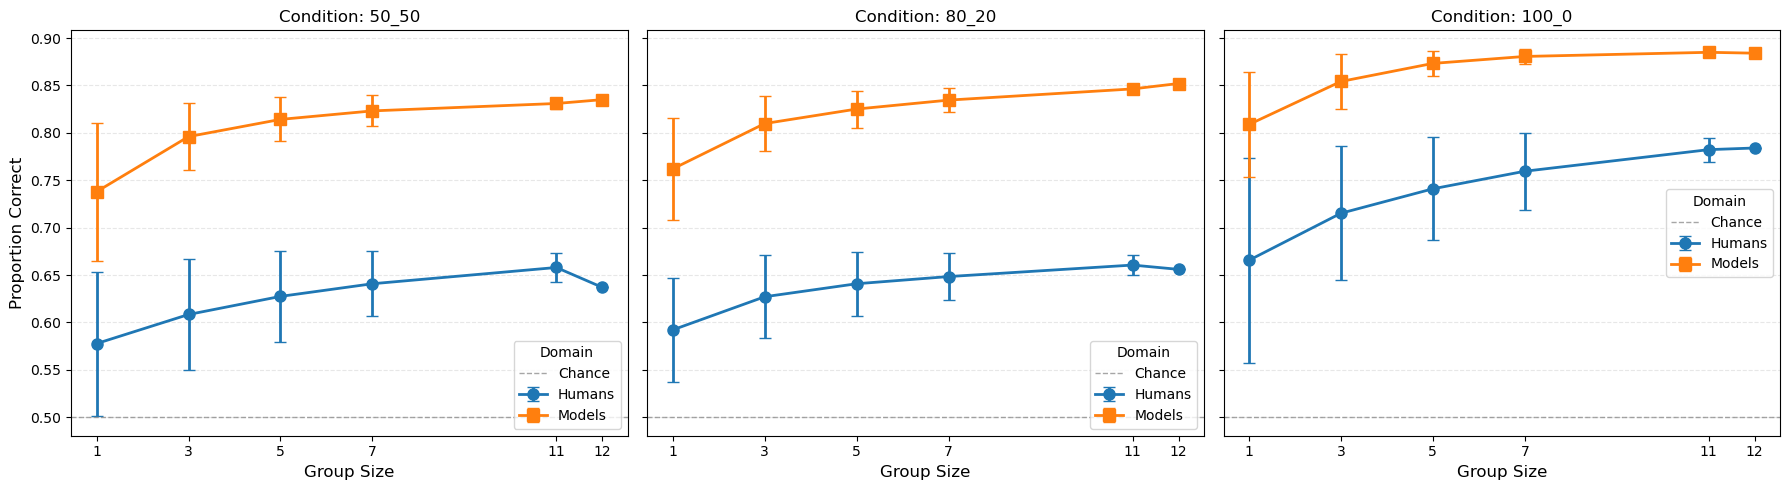

✓ Saved: majority-voting-group-size.pdf


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, cond in zip(axes, conds):
    sub = summary_df[summary_df["condition"] == cond].copy()
    
    for domain, marker, label in [("human", "o-", "Humans"), ("model", "s-", "Models")]:
        dsub = sub[sub["domain"] == domain].sort_values("group_size")
        if dsub.empty:
            continue
        
        ax.errorbar(
            dsub["group_size"],
            dsub["mean_acc"],
            yerr=dsub["std_acc"],
            fmt=marker,
            capsize=4,
            label=label,
            linewidth=2,
            markersize=8
        )
    
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Chance")
    ax.set_xticks(group_sizes)
    ax.set_xlabel("Group Size", fontsize=12)
    ax.set_title(f"Condition: {cond}", fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="Domain")

axes[0].set_ylabel("Proportion Correct", fontsize=12)
plt.tight_layout()
plt.savefig(paths.outputs_dir / "majority-voting-group-size.pdf", bbox_inches="tight")
plt.show()

print("✓ Saved: majority-voting-group-size.pdf")

## 3. Weighted Logic Combiner (WLC) with 10-Fold CV

Trained decision combiner using signal detection theory metrics.

In [6]:
def sdt_metrics(predictions, ground_truth):
    """Compute d', criterion, hit/FA rates from binary predictions."""
    hits = np.sum((predictions == 1) & (ground_truth == 1))
    fas = np.sum((predictions == 1) & (ground_truth == 0))
    n_signal = np.sum(ground_truth == 1)
    n_noise = np.sum(ground_truth == 0)
    
    H = (hits + 0.5) / (n_signal + 1) if n_signal > 0 else np.nan
    F = (fas + 0.5) / (n_noise + 1) if n_noise > 0 else np.nan
    
    accuracy = np.sum(predictions == ground_truth) / len(ground_truth)
    
    if np.isfinite(H) and np.isfinite(F):
        zH = norm.ppf(H)
        zF = norm.ppf(F)
        dprime = zH - zF
        criterion = -0.5 * (zH + zF)
    else:
        dprime = np.nan
        criterion = np.nan
    
    return accuracy, H, F, dprime, criterion

def train_wlc(X_train, y_train):
    """Train WLC weights (least squares on log-odds)."""
    if X_train.shape[0] == 0 or np.all(np.isnan(X_train)):
        return np.zeros(X_train.shape[1]), 0
    
    # Clip to avoid log(0)
    X_clipped = np.clip(X_train, 1e-6, 1 - 1e-6)
    log_odds = np.log(X_clipped / (1 - X_clipped))
    
    # Least squares
    X_design = np.column_stack([log_odds, np.ones(X_clipped.shape[0])])
    try:
        w = np.linalg.lstsq(X_design, y_train, rcond=None)[0]
    except:
        w = np.zeros(X_design.shape[1])
    
    return w[:-1], w[-1]

def apply_wlc(X_test, w, t):
    """Apply trained WLC to test data."""
    X_clipped = np.clip(X_test, 1e-6, 1 - 1e-6)
    log_odds = np.log(X_clipped / (1 - X_clipped))
    pred_odds = np.sum(log_odds * w, axis=1) + t
    pred_prob = 1 / (1 + np.exp(-pred_odds))
    return (pred_prob >= 0.5).astype(int)

print("✓ WLC training functions defined")

✓ WLC training functions defined


In [7]:
def run_wlc_cv(human_df, model_df):
    """Run WLC with 10-fold CV for both domains."""
    rows = []
    
    for domain_label, domain_df in [("Human", human_df), ("Model", model_df)]:
        print(f"\n=== {domain_label.upper()} ===")
        
        for cond in conds:
            dfc = domain_df[domain_df["condition"] == cond].copy()
            if dfc.empty:
                continue
            
            # Extract confidence scores (human) or decision probabilities (model)
            if domain_label == "Human":
                conf_pivot = dfc.pivot(index="stimID", columns="participantID", values="response")
                X = np.clip(conf_pivot.to_numpy() / 7.0, 0, 1).astype(float)  # normalize to [0, 1]
            else:
                # For models, use decision (0/1) as proxy for confidence
                dec_pivot = dfc.pivot(index="stimID", columns="participantID", values="decision")
                X = dec_pivot.to_numpy().astype(float)
            
            y = (
                dfc.drop_duplicates("stimID")
                   .set_index("stimID")["TP"]
                   .reindex(conf_pivot.index if domain_label == "Human" else dec_pivot.index)
                   .to_numpy()
                   .astype(int)
            )
            
            # 10-fold cross-validation
            n_folds = 10
            fold_size = X.shape[0] // n_folds
            
            for fold in range(n_folds):
                test_start = fold * fold_size
                test_end = (fold + 1) * fold_size if fold < n_folds - 1 else X.shape[0]
                
                test_idx = np.arange(test_start, test_end)
                train_idx = np.concatenate([np.arange(0, test_start), np.arange(test_end, X.shape[0])])
                
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                
                w, t = train_wlc(X_train, y_train)
                pred = apply_wlc(X_test, w, t)
                
                acc, hit, fa, dprime, crit = sdt_metrics(pred, y_test)
                
                rows.append({
                    "domain": domain_label,
                    "condition": cond,
                    "fold": fold,
                    "accuracy": acc,
                    "hit_rate": hit,
                    "fa_rate": fa,
                    "dprime": dprime,
                    "criterion": crit
                })
            
            print(f"  {cond}: WLC CV complete")
    
    return pd.DataFrame(rows)

wlc_results = run_wlc_cv(human_master, model_master)
print(f"\n✓ WLC analysis complete ({len(wlc_results)} folds)")
display(wlc_results.head(10))


=== HUMAN ===
  50_50: WLC CV complete
  80_20: WLC CV complete
  100_0: WLC CV complete

=== MODEL ===
  50_50: WLC CV complete
  80_20: WLC CV complete
  100_0: WLC CV complete

✓ WLC analysis complete (60 folds)


,domain,condition,fold,accuracy,hit_rate,fa_rate,dprime,criterion
0,Human,50_50,0,0.46,0.987179,0.865079,1.128178,-1.667517
1,Human,50_50,1,0.55,0.989583,0.842593,1.305821,-1.658081
2,Human,50_50,2,0.60,0.990196,0.794118,1.512976,-1.577280
3,Human,50_50,3,0.63,0.991071,0.815217,1.471279,-1.632928
4,Human,50_50,4,0.58,0.989796,0.801887,1.470378,-1.583569
5,Human,50_50,5,0.59,0.990196,0.813725,1.442060,-1.612739
6,Human,50_50,6,0.62,0.991071,0.836957,1.386541,-1.675297
7,Human,50_50,7,0.58,0.990196,0.833333,1.366347,-1.650595
8,Human,50_50,8,0.64,0.973684,0.788889,1.135360,-1.370252
9,Human,50_50,9,0.60,0.990385,0.810000,1.463131,-1.609462


### WLC Results Summary

In [8]:
wlc_summary = (
    wlc_results
    .groupby(["domain", "condition"])
    .agg({
        "accuracy": ["mean", "std"],
        "dprime": ["mean", "std"],
        "hit_rate": ["mean", "std"],
        "fa_rate": ["mean", "std"]
    })
    .round(3)
)

display(wlc_summary)

# Save results
results_df.to_csv(paths.outputs_dir / "majority-voting-bootstrap.csv", index=False)
wlc_results.to_csv(paths.outputs_dir / "wlc-cv-results.csv", index=False)
print(f"\n✓ Saved results to outputs/")

accuracy        dprime        hit_rate        fa_rate       
                     mean    std   mean    std     mean    std    mean    std
domain condition                                                             
Human  100_0        0.658  0.054  1.857  0.203    0.990  0.001   0.680  0.073
       50_50        0.585  0.051  1.368  0.138    0.988  0.005   0.820  0.024
       80_20        0.572  0.049  1.273  0.221    0.990  0.001   0.850  0.052
Model  100_0        0.595  0.074  1.329  0.299    0.983  0.012   0.792  0.109
       50_50        0.642  0.044  1.611  0.320    0.982  0.010   0.704  0.050
       80_20        0.650  0.055  1.736  0.200    0.986  0.008   0.691  0.067


✓ Saved results to outputs/


## Summary

**Key Findings:**
- Compare human vs model accuracy across group sizes
- WLC improves performance over individual agents
- Signal detection metrics show condition effects on discriminability (d')